# Notebook 04 — Decision Cost Metric

RMSE treats over- and under-forecasting as equally bad. They are not.

In demand forecasting, **under-forecasting** (stock-out, lost revenue) typically costs 3× more than **over-forecasting** (excess inventory). We define a configurable asymmetric cost and show how model rankings flip.

In [1]:
import json
import logging
import warnings
from pathlib import Path

logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100})

FIGURES_DIR = Path("outputs/figures")
RESULTS_DIR = Path("outputs/results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig: plt.Figure, name: str) -> None:
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight", dpi=120)
    print(f"Saved figure → {path}")


def save_json(data, name: str) -> None:
    path = RESULTS_DIR / name
    if isinstance(data, pd.DataFrame):
        payload = data.to_dict(orient="records")
    else:
        payload = data
    path.write_text(json.dumps(payload, indent=2, default=str))
    print(f"Saved results → {path}")


print("Ready.")


Ready.


In [2]:
from src.datasets.loader import load_airline, load_electricity, load_retail_base
from src.datasets.injector import inject_anomalies, ANOMALY_EVENTS

airline     = load_airline()
electricity = load_electricity()
retail_base = load_retail_base()
retail      = inject_anomalies(retail_base)

for name, s in [("Airline", airline), ("Electricity", electricity), ("Retail", retail)]:
    print(f"{name:15s}  {len(s):4d} pts  "
          f"{s.index[0].date()} → {s.index[-1].date()}  mean={s.mean():.1f}")


Airline           144 pts  1949-01-01 → 1960-12-01  mean=280.3
Electricity       397 pts  1990-01-01 → 2023-01-01  mean=132.1
Retail            208 pts  2020-01-06 → 2023-12-25  mean=545.6


In [3]:
from src.models.naive import SeasonalNaive
from src.models.arima import ARIMAModel
from src.models.prophet_model import ProphetModel
from src.models.xgboost_model import XGBoostModel
from src.models.lstm_model import LSTMModel

# LSTM uses reduced config for notebook speed; set INCLUDE_LSTM=True to enable
INCLUDE_LSTM = False


def make_factories(period: int = 12) -> dict:
    # Period-aware lag sets: monthly captures 2-year cycle; weekly captures annual (52w)
    if period == 52:
        lags = [1, 2, 3, 4, 13, 26]   # no lag-52: needs 52+ train pts, starves early cutoffs
        rolling = [4, 13, 26]
        arima_seasonal = (0, 0, 0, 0)  # seasonal ARIMA with period=52 is prohibitively slow
    else:
        lags = [1, 2, 3, 6, 12, 24]
        rolling = [3, 6, 12]
        arima_seasonal = (1, 1, 1, period)

    factories = {
        "Naive":   lambda: SeasonalNaive(period=period),
        "ARIMA":   lambda: ARIMAModel(order=(1, 1, 1), seasonal_order=arima_seasonal),
        "Prophet": ProphetModel,
        "XGBoost": lambda: XGBoostModel(n_estimators=100, max_depth=3,
                                         learning_rate=0.05, subsample=0.8,
                                         lags=lags, rolling_windows=rolling),
    }
    if INCLUDE_LSTM:
        factories["LSTM"] = lambda: LSTMModel(hidden_size=16, num_layers=2, epochs=20,
                                               seq_len=period)
    return factories


DATASETS = {
    "Airline":     (airline,     12),
    "Electricity": (electricity, 12),
    "Retail":      (retail,      52),
}


Importing plotly failed. Interactive plots will not work.


## The decision-cost function

```python
def decision_cost(y_true, y_pred, cost_under=3.0, cost_over=1.0):
    errors = y_true - y_pred  # positive → under-forecast
    costs = np.where(errors > 0, errors * cost_under, -errors * cost_over)
    return costs.mean()
```

At ratio 3:1, one unit of under-forecast costs three times as much as one unit of over-forecast.

In [4]:
from src.evaluation.metrics import decision_cost, rmse
from src.evaluation.backtest import expanding_window_backtest

N_CUTOFFS = 6
COST_UNDER = 3.0
COST_OVER  = 1.0

records = []
for ds_name, (series, period) in DATASETS.items():
    min_train = 36 if period == 12 else 60
    for model_name, factory in make_factories(period).items():
        df = expanding_window_backtest(
            series, factory, n_cutoffs=N_CUTOFFS, min_train_size=min_train,
            cost_under=COST_UNDER, cost_over=COST_OVER,
        )
        records.append({
            "Dataset":      ds_name,
            "Model":        model_name,
            "RMSE":         df["rmse"].mean(),
            "DecisionCost": df["decision_cost"].mean(),
        })
    print(f"Done: {ds_name}")

perf = pd.DataFrame(records).round(3)
save_json(perf, "04_rmse_vs_decision_cost.json")


/workspaces/timeseries_evaluation_arena/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


13:28:02 - cmdstanpy - INFO - Chain [1] start processing


13:28:02 - cmdstanpy - INFO - Chain [1] done processing


13:28:02 - cmdstanpy - INFO - Chain [1] start processing


13:28:03 - cmdstanpy - INFO - Chain [1] done processing


...

13:28:09 - cmdstanpy - INFO - Chain [1] start processing


13:28:09 - cmdstanpy - INFO - Chain [1] done processing


13:28:09 - cmdstanpy - INFO - Chain [1] start processing


13:28:09 - cmdstanpy - INFO - Chain [1] done processing


Done: Retail
Saved results → outputs/results/04_rmse_vs_decision_cost.json


## RMSE rankings vs Decision-Cost rankings

In [5]:
for ds_name in ["Airline", "Electricity", "Retail"]:
    sub = perf[perf["Dataset"] == ds_name].set_index("Model")
    sub["RMSE_rank"]  = sub["RMSE"].rank().astype(int)
    sub["Cost_rank"]  = sub["DecisionCost"].rank().astype(int)
    sub["Rank_delta"] = sub["Cost_rank"] - sub["RMSE_rank"]
    print(f"\n=== {ds_name} ===")
    display(sub[["RMSE", "RMSE_rank", "DecisionCost", "Cost_rank", "Rank_delta"]]
              .sort_values("RMSE_rank"))



=== Airline ===


,RMSE,RMSE_rank,DecisionCost,Cost_rank,Rank_delta
Model,,,,,
ARIMA,8.354,1,12.908,1,0
XGBoost,15.424,2,32.458,2,0
Prophet,24.327,3,41.756,3,0
Naive,30.000,4,90.000,4,0



=== Electricity ===


,RMSE,RMSE_rank,DecisionCost,Cost_rank,Rank_delta
Model,,,,,
Prophet,4.311,1,12.477,1,0
ARIMA,5.083,2,14.088,2,0
Naive,6.191,3,18.572,3,0
XGBoost,19.806,4,59.418,4,0



=== Retail ===


,RMSE,RMSE_rank,DecisionCost,Cost_rank,Rank_delta
Model,,,,,
XGBoost,16.466,1,35.397,2,1
ARIMA,16.494,2,27.881,1,-1
Prophet,21.000,3,38.488,3,0
Naive,34.579,4,82.211,4,0


## Visualise: RMSE vs Decision Cost scatter

Saved figure → outputs/figures/04_rmse_vs_cost.png


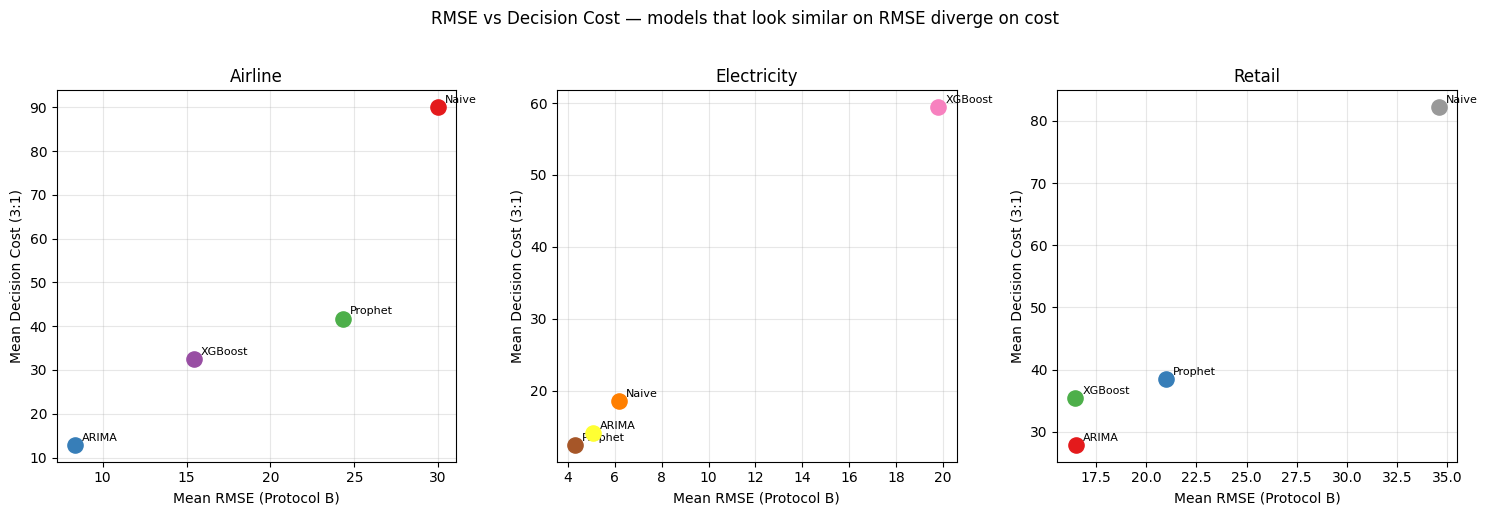

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = plt.cm.Set1.colors

for ax, ds_name in zip(axes, ["Airline", "Electricity", "Retail"]):
    sub = perf[perf["Dataset"] == ds_name]
    for i, row in sub.iterrows():
        ax.scatter(row["RMSE"], row["DecisionCost"], s=120, color=colors[i % len(colors)],
                   zorder=5)
        ax.annotate(row["Model"], (row["RMSE"], row["DecisionCost"]),
                    textcoords="offset points", xytext=(5, 3), fontsize=8)
    ax.set_xlabel("Mean RMSE (Protocol B)")
    ax.set_ylabel("Mean Decision Cost (3:1)")
    ax.set_title(ds_name)
    ax.grid(alpha=0.3)

plt.suptitle("RMSE vs Decision Cost — models that look similar on RMSE diverge on cost",
             y=1.02)
plt.tight_layout()
save_fig(fig, "04_rmse_vs_cost.png")
plt.show()


## Sensitivity: how rankings change with the cost ratio

13:28:11 - cmdstanpy - INFO - Chain [1] start processing


13:28:11 - cmdstanpy - INFO - Chain [1] done processing


13:28:11 - cmdstanpy - INFO - Chain [1] start processing


13:28:11 - cmdstanpy - INFO - Chain [1] done processing


13:28:11 - cmdstanpy - INFO - Chain [1] start processing


...

13:28:17 - cmdstanpy - INFO - Chain [1] start processing


13:28:17 - cmdstanpy - INFO - Chain [1] done processing


13:28:17 - cmdstanpy - INFO - Chain [1] start processing


13:28:18 - cmdstanpy - INFO - Chain [1] done processing


Saved results → outputs/results/04_cost_sensitivity.json
Saved figure → outputs/figures/04_cost_sensitivity.png


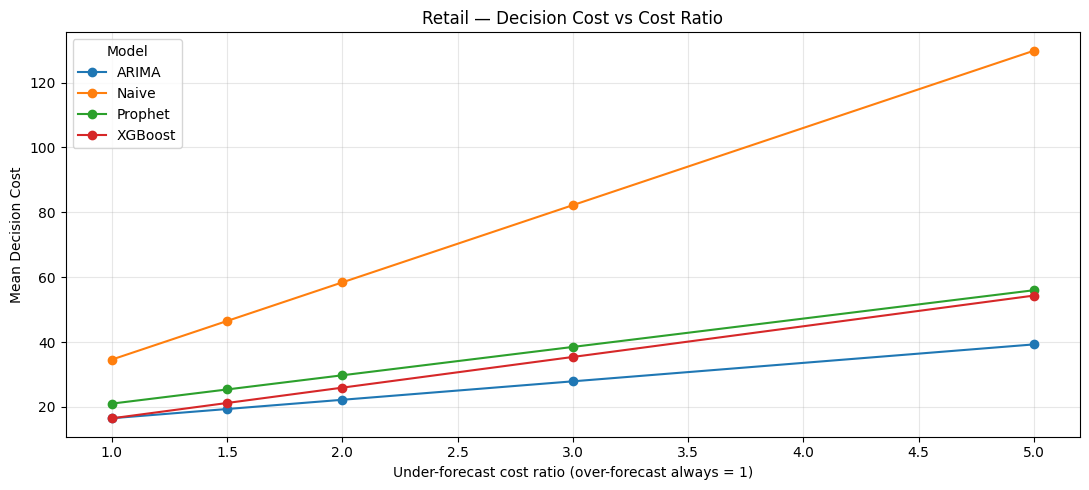

In [7]:
cost_ratios = [1.0, 1.5, 2.0, 3.0, 5.0]
ratio_records = []

series, period = DATASETS["Retail"]
min_train = 60

for ratio in cost_ratios:
    for model_name, factory in make_factories(period).items():
        df = expanding_window_backtest(
            series, factory, n_cutoffs=N_CUTOFFS, min_train_size=min_train,
            cost_under=ratio, cost_over=1.0,
        )
        ratio_records.append({
            "CostRatio": ratio,
            "Model": model_name,
            "DecisionCost": df["decision_cost"].mean(),
        })

ratio_df = pd.DataFrame(ratio_records)
save_json(ratio_df, "04_cost_sensitivity.json")
pivot = ratio_df.pivot(index="CostRatio", columns="Model", values="DecisionCost")

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(ax=ax, marker="o")
ax.set_xlabel("Under-forecast cost ratio (over-forecast always = 1)")
ax.set_ylabel("Mean Decision Cost")
ax.set_title("Retail — Decision Cost vs Cost Ratio")
ax.legend(title="Model")
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, "04_cost_sensitivity.png")
plt.show()


## Conclusion

- At cost ratio 1:1, decision cost ≡ MAE — rankings match RMSE closely.
- As the ratio increases toward 3:1 and 5:1, models that **systematically under-forecast** (e.g., by anchoring to seasonal means) are penalised disproportionately.
- **Pick your metric before you pick your model.** The "best" model depends entirely on what error costs your business.

Next: *why* some models under-forecast and others do not — the calendar-memorisation problem.